# Project: Computational immunophenotyping of biomaterial-induced foreign body response
---
**Notebook**: 04_interaction_analysis

**Dataset:** [GSE203099](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE203099)  
**Author:** *Chinonye Precious Anams*


## 1. Biological context and objective

### 1.1 Immune–Fibroblast Crosstalk
Fibrosis at biomaterial interfaces does not occur in isolation; it emerges from coordinated signaling between **immune cells** (especially macrophages) and **fibroblasts**. 

While scRNA-seq does not directly measure secreted proteins or physical cell–cell contact, transcriptional data enables **hypothesis-generating inference**. By identifying the co-expression of candidate **ligand–receptor (L–R) pairs**, we can map the potential signaling highways enriched between these populations.

### 1.2 Objective: In silico Interaction Mapping
The objective of this analysis is to leverage the macrophage and fibroblast subsets to infer candidate **Immune $\rightarrow$ Fibroblast** signaling interactions specifically associated with fibroblast activation and **ECM programs**.

**Methodological Goals:**
1.  **L–R Inference:** Identify statistically significant ligand-receptor interactions (e.g., using tools like *CellChat* or *NicheNet*).
2.  **Pathway Enrichment:** Determine which signaling pathways (e.g., *TGF-$\beta$*, *PDGF*, *CCL*) are most active in the biomaterial-induced response.
3.  **Cross-Validation Preparation:** Identify high-confidence candidates for downstream validation.

> **Research Note:** Findings are interpreted as associations that motivate validation using **orthogonal assays**, such as spatial profiling, cytokine measurements, or perturbation experiments.

---

### Metadata

In [1]:
"""
Project: Computational immunophenotyping of biomaterial-induced foreign body response
Dataset: GSE203099
Aim: To infer immune–fibroblast interactions underlying biomaterial-induced fibrosis
using macrophage state–specific signaling and fibroblast activation programs.
Author: Chinonye Precious Anams
"""

'\nProject: Computational immunophenotyping of biomaterial-induced foreign body response\nDataset: GSE203099\nAim: To infer immune–fibroblast interactions underlying biomaterial-induced fibrosis\nusing macrophage state–specific signaling and fibroblast activation programs.\nAuthor: Chinonye Precious Anams\n'

## 2. Imports, settings, and figure saving

In [14]:
from pathlib import Path
import scanpy as sc
from scipy.stats import zscore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fig_dir = Path("../figures/crosstalk")
fig_dir.mkdir(parents=True, exist_ok=True)

## 3. Load processed macrophage and fibroblast state objects

In [4]:
adata_mac = sc.read_h5ad("../data/processed/GSE203099_macrophage_states.h5ad")
adata_fib = sc.read_h5ad("../data/processed/GSE203099_fibroblast_states.h5ad")

adata_mac, adata_fib

(AnnData object with n_obs × n_vars = 28379 × 21617
     obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'Inflammatory_score', 'Interferon_score', 'Antigen_presentation_score', 'Phagocytosis_lysosome_score', 'Remodeling_wound_heal_score', 'Pro_fibrotic_associated_score', 'mac_state'
     var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'mac_state_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 5006 × 21617
     obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'ECM_score', 'Myofibroblast_score', 'TGFb_response_score', 'fib_state'
     var: 'mt', 'n_cells_by_counts',

In [5]:
adata_mac.obs["mac_state"].value_counts()

mac_state
Other_macrophage                      19999
Pro_fibrotic_associated_macrophage     8380
Name: count, dtype: int64

In [7]:
adata_fib.obs["fib_state"].value_counts()

fib_state
Other_fibroblasts       3185
ECM_high_fibroblasts    1821
Name: count, dtype: int64

## 4. Define “sender” and “receiver” groups (macrophage → fibroblast)

### 4.1 Rationale (Markdown)

To keep interpretation focused and fibrosis-relevant, the analysis is restricted to **macrophage → fibroblast** signaling. Macrophage sub-states (including a conservative pro-fibrotic–associated category) are treated as “senders”, and fibroblast subclusters are treated as “receivers”.


### 4.2 Ensure group columns exist

In [8]:
# Sender groups (macrophage states)
sender_col = "mac_state"

# Receiver groups (fibroblast states)
receiver_col = "fib_state"

## 5. Candidate ligand–receptor panel (focused, fibrosis-relevant)

### 5.1 Why a focused panel
Because full ligand–receptor inference can be sensitive to modeling choices and database versions, we first perform a conservative, focused screen using a small panel of well-established macrophage/fibroblast signaling axes relevant to inflammation and fibrotic remodeling. This provides interpretable candidates for downstream validation.


### 5.2 Define candidate ligand–receptor pairs

In [9]:
# Focused panel: macrophage-derived ligands and their common fibroblast receptors
lr_pairs = [
    ("Tgfb1", "Tgfbr1"),
    ("Tgfb1", "Tgfbr2"),
    ("Pdgfb", "Pdgfrb"),
    ("Pdgfa", "Pdgfra"),
    ("Il1b", "Il1r1"),
    ("Tnf", "Tnfrsf1a"),
    ("Ccl2", "Ccr2"),
    ("Ccl3", "Ccr1"),
    ("Ccl4", "Ccr5"),
    ("Spp1", "Cd44"),
    ("Spp1", "Itgav"),
    ("Csf1", "Csf1r"),
]

## 6. Compute simple expression summaries per group

In [10]:
def mean_expr_by_group(adata, genes, groupby):
    genes_present = [g for g in genes if g in adata.var_names]
    if len(genes_present) == 0:
        return pd.DataFrame()
    X = adata[:, genes_present].X
    # Convert sparse to dense safely if needed
    if hasattr(X, "toarray"):
        X = X.toarray()
    df = pd.DataFrame(X, columns=genes_present, index=adata.obs_names)
    df[groupby] = adata.obs[groupby].values
    return df.groupby(groupby, observed=True).mean()

ligands = sorted(set([l for l, r in lr_pairs]))
receptors = sorted(set([r for l, r in lr_pairs]))

ligand_means = mean_expr_by_group(adata_mac, ligands, sender_col)
receptor_means = mean_expr_by_group(adata_fib, receptors, receiver_col)

ligand_means.head(), receptor_means.head()

(                                        Ccl2      Ccl3      Ccl4      Csf1  \
 mac_state                                                                    
 Other_macrophage                    0.037024 -0.042138 -0.023865 -0.048772   
 Pro_fibrotic_associated_macrophage -0.088357  0.100564  0.056954  0.116191   
 
                                         Il1b     Pdgfa     Pdgfb      Spp1  \
 mac_state                                                                    
 Other_macrophage                   -0.083755 -0.034282 -0.081223 -0.138726   
 Pro_fibrotic_associated_macrophage  0.199882  0.081815  0.193839  0.331073   
 
                                        Tgfb1       Tnf  
 mac_state                                               
 Other_macrophage                   -0.091369 -0.077575  
 Pro_fibrotic_associated_macrophage  0.218053  0.185133  ,
                           Ccr1      Ccr2      Ccr5      Cd44     Csf1r  \
 fib_state                                              

## 7. Score candidate interactions (sender ligand × receiver receptor)

In [11]:
rows = []
for ligand, receptor in lr_pairs:
    if ligand in ligand_means.columns and receptor in receptor_means.columns:
        for sender in ligand_means.index:
            for recv in receptor_means.index:
                score = ligand_means.loc[sender, ligand] * receptor_means.loc[recv, receptor]
                rows.append({
                    "ligand": ligand,
                    "receptor": receptor,
                    "sender": sender,
                    "receiver": str(recv),
                    "interaction_score": score
                })

lr_scores = pd.DataFrame(rows).sort_values("interaction_score", ascending=False)
lr_scores.head(15)

,ligand,receptor,sender,receiver,interaction_score
38,Spp1,Cd44,Pro_fibrotic_associated_macrophage,ECM_high_fibroblasts,0.152365
42,Spp1,Itgav,Pro_fibrotic_associated_macrophage,ECM_high_fibroblasts,0.043610
37,Spp1,Cd44,Other_macrophage,Other_fibroblasts,0.036502
19,Il1b,Il1r1,Pro_fibrotic_associated_macrophage,Other_fibroblasts,0.030182
11,Pdgfb,Pdgfrb,Pro_fibrotic_associated_macrophage,Other_fibroblasts,0.029267
7,Tgfb1,Tgfbr2,Pro_fibrotic_associated_macrophage,Other_fibroblasts,0.024463
30,Ccl3,Ccr1,Pro_fibrotic_associated_macrophage,ECM_high_fibroblasts,0.022746
16,Il1b,Il1r1,Other_macrophage,ECM_high_fibroblasts,0.022120
8,Pdgfb,Pdgfrb,Other_macrophage,ECM_high_fibroblasts,0.021449
27,Ccl2,Ccr2,Pro_fibrotic_associated_macrophage,Other_fibroblasts,0.018253


In [12]:
lr_scores.to_csv("../data/processed/macrophage_fibroblast_lr_scores.csv", index=False)

## 8. Visualize top candidate interactions

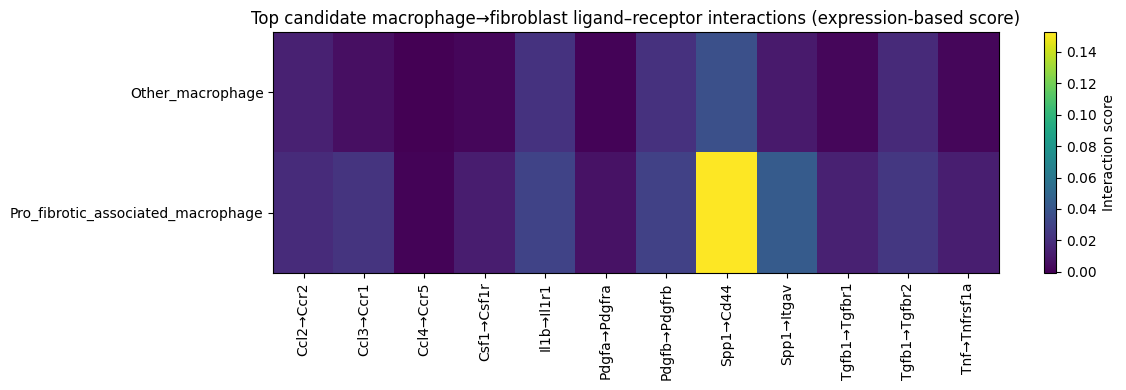

In [18]:
#Heatmap of top interactions (aggregated)
topN = 30
top = lr_scores.head(topN).copy()
top["pair"] = top["ligand"] + "→" + top["receptor"]

pivot = top.pivot_table(
    index="sender",
    columns="pair",
    values="interaction_score",
    aggfunc="mean",
    fill_value=0
)

plt.figure(figsize=(12, 4))
im = plt.imshow(pivot.values, aspect="auto", cmap="viridis")
plt.colorbar(im, label="Interaction score")
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=90)
plt.title("Top candidate macrophage→fibroblast ligand–receptor interactions (expression-based score)")
plt.tight_layout()
plt.savefig(fig_dir / "top_lr_interactions_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

This ligand–receptor screen identifies candidate macrophage→fibroblast signaling axes based on transcriptional co-expression and should be interpreted as hypothesis-generating. Notably, top-ranked interactions included SPP1–CD44 and SPP1–ITGAV from pro-fibrotic–associated macrophages toward ECM-high fibroblasts, alongside remodeling-associated pathways such as TGFB1–TGFBR1/2, PDGFB–PDGFRB, IL1B–IL1R1, and chemokine interactions (CCL2–CCR2, CCL3–CCR1). These candidate axes can be prioritized for validation using spatial localization and protein-level cytokine assays.


## 10. Future work / validation direction

**Future validation directions (suggested):**
1. Spatial profiling (e.g., spatial transcriptomics or immunostaining) to test whether predicted macrophage ligands and fibroblast receptors are co-localized at the biomaterial–tissue interface.
2. Protein-level assays (e.g., ELISA or multiplex) to assess whether candidate macrophage-derived ligands (such as SPP1, TGFB1, or PDGFB) are differentially enriched in fibrotic versus non-fibrotic biomaterial contexts.
3. Targeted CRISPR-based perturbations of selected macrophage-expressed ligands or pathways to evaluate their influence on fibroblast activation programs in controlled co-culture or implant-associated models.
